In [1]:
import pandas as pd 
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
orders = pd.read_csv(r"C:\Users\Harshita Sahu\OneDrive\Documents\4_project_Toys\orders.csv")
orders.head()

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49


In [3]:
user_counts_orders = orders.groupby('user_id')['order_id'].count().reset_index(name = 'user_counts')
user_counts_orders[user_counts_orders['user_counts']>1]['user_id'].nunique() 

591

In [4]:
user_counts_orders[user_counts_orders['user_counts']>1]['user_id'].nunique()*100.00/user_counts_orders['user_id'].nunique()

1.8645885916203937

In [5]:
user_counts_orders[user_counts_orders['user_counts']==1]['user_id'].nunique()*100.00/ user_counts_orders['user_id'].nunique()

98.13541140837961

In [6]:
user_counts_orders[user_counts_orders['user_counts']==1]['user_id'].nunique() 

31105

In [7]:
order_items = pd.read_csv(r"C:\Users\Harshita Sahu\OneDrive\Documents\4_project_Toys\order_items.csv")
order_items.head()

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49


In [8]:
order_items_refunds = pd.read_csv(r"C:\Users\Harshita Sahu\OneDrive\Documents\4_project_Toys\order_item_refunds.csv")
order_items_refunds.head()

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99


In [9]:
website_sessions =  pd.read_csv(r"C:\Users\Harshita Sahu\OneDrive\Documents\4_project_Toys\website_sessions.csv")
website_sessions.head()

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
0,1,19-03-2012 08:04,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
1,2,19-03-2012 08:16,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
2,3,19-03-2012 08:26,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
3,4,19-03-2012 08:37,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
4,5,19-03-2012 09:00,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com


In [10]:
website_pageviews =  pd.read_csv(r"C:\Users\Harshita Sahu\OneDrive\Documents\4_project_Toys\website_pageviews.csv")
website_pageviews.head()

,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:16,1,/home
1,2,2012-03-19 08:16:49,2,/home
2,3,2012-03-19 08:26:55,3,/home
3,4,2012-03-19 08:37:33,4,/home
4,5,2012-03-19 09:00:55,5,/home


In [11]:
products = pd.read_csv(r"C:\Users\Harshita Sahu\OneDrive\Documents\4_project_Toys\products.csv")
products.head()

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [16]:
website_pageviews['created_at'] = pd.to_datetime(website_pageviews['created_at'])

In [33]:
### ab testing 

launch_date_billing_2 = website_pageviews[website_pageviews['pageview_url'] == '/billing-2']['created_at'].min()
after_launch_3_months = launch_date_billing_2 + pd.DateOffset(months = 3)
before_launch_3_months = launch_date_billing_2 - pd.DateOffset(months = 3)
wb = website_pageviews[(website_pageviews['created_at']> before_launch_3_months) & (website_pageviews['created_at']< after_launch_3_months)]
wb_filtered = wb[wb['pageview_url'].isin(['/billing','/billing-2'])]
wb_filtered = wb_filtered.merge(orders, on = 'website_session_id',how = 'left',suffixes = ('_wb','_orders'))
compare = wb_filtered.groupby('pageview_url').agg(Total_orders = ('order_id','nunique'),Total_sessions = ('website_session_id','nunique'))
compare['conversion_rate'] = compare['Total_orders']*100.0/compare['Total_sessions']
compare

,Total_orders,Total_sessions,conversion_rate
pageview_url,,,
/billing,1144,2527,45.271072
/billing-2,789,1272,62.028302


In [27]:
order_items['created_at'] = pd.to_datetime(order_items['created_at'])

In [28]:

order_r_i = order_items.merge(order_items_refunds, on = 'order_item_id', how = 'left',suffixes= ('_order_items','_order_items_refunds'))
order_r_i['profit'] = ((order_r_i['price_usd'] - np.where(order_r_i['refund_amount_usd'].fillna(0) == 0 , 0,order_r_i['refund_amount_usd']))-
(order_r_i['cogs_usd'] - np.where(order_r_i['refund_amount_usd'].fillna(0) == 0 , 0,order_r_i['cogs_usd'])))

In [29]:
order_r_i['profit'].sum()

1162780.0

In [30]:
order_r_i['quarter'] = order_r_i['created_at_order_items'].dt.quarter
order_r_i['years'] = order_r_i['created_at_order_items'].dt.year

grouped = order_r_i.groupby(['quarter','years'])['profit'].sum()
grouped= grouped.reset_index(name = 'profit')
grouped.sort_values(by = ['quarter','years'],inplace = True)

grouped['prev_year_profit'] = grouped.groupby('quarter')['profit'].shift(1)
((grouped['profit'] - grouped['prev_year_profit']) *100.00/ grouped['prev_year_profit'])

0             NaN
1     2051.708808
2      199.284607
3       80.167497
4             NaN
5      408.852459
6      193.941346
7             NaN
8      190.213612
9      174.324763
10            NaN
11     101.857217
12     169.241720
dtype: float64

In [101]:

website_sessions['channel_type'] = website_sessions['utm_source'].apply(lambda x: 'Paid' if x in ['gsearch','socialbook','bsearch'] else 'Free')
conditions = [(website_sessions['utm_source'].isin(['gsearch','bsearch'])),
(website_sessions['utm_source']=='socialbook'),
((website_sessions['utm_source']== 'not applicable') & (website_sessions['http_referer'].str.contains('gsearch',na = False))),
((website_sessions['utm_source']== 'not applicable') & (website_sessions['http_referer'].str.contains('bsearch',na = False))),
((website_sessions['utm_source']== 'not applicable') & (website_sessions['http_referer'].str.contains('socialbook',na = False)))]

choices = ['Paid_Search','Paid_Social','Organic_Search','Organic_Search','Organic Social']

website_sessions['channel_name'] = np.select(conditions,choices,default = 'Direct')

In [102]:

order_items_order_refunds = order_items.merge(order_items_refunds,on = 'order_item_id',how = 'left',suffixes= ('_order_items','_order_items_refund'))

In [103]:
order_items_order_refunds['refund_amount_usd'] = order_items_order_refunds['refund_amount_usd'].fillna(0)
order_items_order_refunds['price_refund_amt'] = (order_items_order_refunds['price_usd'] - np.where(order_items_order_refunds['refund_amount_usd']==0,0,order_items_order_refunds['refund_amount_usd']))

In [104]:
order_items_order_refunds['cost_refund_amt'] = (order_items_order_refunds['cogs_usd'] - np.where(order_items_order_refunds['refund_amount_usd'].fillna(0)==0,0,order_items_order_refunds['cogs_usd']))

In [105]:

order_items_order_refunds['items_profit'] = order_items_order_refunds['price_refund_amt'] - order_items_order_refunds['cost_refund_amt']
order_items_order_refunds['profit_margin'] = order_items_order_refunds['items_profit']/order_items_order_refunds['price_refund_amt']

In [106]:
orders['order_id'].nunique()

32313

In [107]:
orders[orders.groupby('user_id')['order_id'].transform('count')==1]['user_id'].nunique()*100.00/orders['user_id'].nunique()

98.13541140837961

In [108]:
order_items_order_refunds['items_profit'].sum()*100.00/ order_items_order_refunds['cost_refund_amt'].sum()

168.4233860154562

In [109]:

website_sessions['website_session_id'].nunique()- website_sessions[website_sessions['is_repeat_session'] >0]['website_session_id'].nunique()

394318

# Business KPIS 

In [110]:
Total_orders   = orders['order_id'].nunique()
Net_revenue  =order_items_order_refunds['price_refund_amt'].sum()
Total_profit   = order_items_order_refunds['items_profit'].sum()
Profit_percent = (order_items_order_refunds['items_profit'].sum()*100.00/order_items_order_refunds['cost_refund_amt'].sum())
Total_customer = orders['user_id'].nunique()
Repeat_customer= user_orders_count = orders.groupby('user_id')['order_id'].count().reset_index(name = 'order_counts')
Repeat_customer = user_orders_count[user_orders_count['order_counts']>1].count()['user_id']
Profit_per_cust = Total_profit/orders['user_id'].count()
Total_gross_revenue = orders['price_usd'].sum()
Avg_order_value = Total_gross_revenue/Total_orders
Profit_Margin = (order_items_order_refunds['items_profit'].sum()*100.00/order_items_order_refunds['price_refund_amt'].sum())
Total_Profit_Margin = order_items_order_refunds['profit_margin'].sum()
Order_items_level_refund_rate = order_items_refunds['order_item_id'].nunique()/order_items['order_item_id'].nunique()*100.00
Order_level_refund_rate = order_items_refunds['order_id'].nunique()/order_items['order_id'].nunique()*100.00
No_of_session  = website_sessions['website_session_id'].nunique()
print(f"""Total_orders :{Total_orders},Total_Net_revenue :{Net_revenue} , Total_profit :{Total_profit} , Total_customer : {Total_customer},\
Repeat_customer : {Repeat_customer} ,Profit_per_cust : {Profit_per_cust},Avg_order_value : {Avg_order_value},\
 Profit_Margin : {Profit_Margin},Total_Profit_Margin:{Total_Profit_Margin}  \
, Order_items_level_refund_rate : {Order_items_level_refund_rate}
, Order_level_refund_rate :{Order_level_refund_rate} , No_of_session :{No_of_session}""")

Total_orders :32313,Total_Net_revenue :1853171.0599999998 , Total_profit :1162780.0 , Total_customer : 31696,Repeat_customer : 591 ,Profit_per_cust : 35.98489771918423,Avg_order_value : 59.99163649305234, Profit_Margin : 62.74542189321692,Total_Profit_Margin:24163.141928734723  , Order_items_level_refund_rate : 4.324797001873828
, Order_level_refund_rate :5.332219230650203 , No_of_session :472871


In [111]:
### Total Gross Revenue 
orders['price_usd'].sum()
### Total Gross Cost 
orders['cogs_usd'].sum()
### order_items_refund_rate 
order_items_order_refunds['order_item_refund_id'].nunique()*100.00/order_items_order_refunds['order_item_id'].nunique()
### Total Net Revenue --
order_items_order_refunds['price_refund_amt'].sum()
#### Total Customers
orders['user_id'].nunique()
### Repeat Customer Rate ---
orders[orders.groupby('user_id')['order_id'].transform('count')>1]['user_id'].nunique()*100.00/orders['user_id'].nunique()
### One - Time Customer Rate ---
orders[orders.groupby('user_id')['order_id'].transform('count')==1]['user_id'].nunique()*100.00/orders['user_id'].nunique()
### Refund Order Rate --
order_items_order_refunds['order_id_order_items_refund'].nunique()*100.00/ orders['order_id'].nunique()
#### Profit Margin 
order_items_order_refunds['items_profit'].sum()*100.00/order_items_order_refunds['price_refund_amt'].sum()
### Total Profit 
order_items_order_refunds['items_profit'].sum()
#### Total Cost
order_items_order_refunds['cost_refund_amt'].sum()
### Total Refunded Amounts 
order_items_order_refunds['refund_amount_usd'].sum()
#### Avg Gross Order Value
orders['price_usd'].mean()
### order_items refunded cost 
orr = order_items.merge(order_items_refunds, on = 'order_item_id',how = 'left',suffixes=('_order_items','_order_items_refunds'))
orr['refunds_costsss'] = np.where(orr['refund_amount_usd'].fillna(0)==0,0,orr['cogs_usd'])
orr['refunds_costsss'].sum()
### Refunded Amount %
orr['refund_amount_usd'].sum()*100.00/orr['price_usd'].sum()
#### Total Refunded Items 
order_items_refunds['order_item_id'].nunique()
### Profit Percentages
order_items_order_refunds['items_profit'].sum()*100.00/ order_items_order_refunds['cost_refund_amt'].sum()
### Total Website Sessions---
website_sessions['website_session_id'].nunique()
#### Repeat Sessions Rate 
website_sessions[website_sessions['is_repeat_session'] >0]['website_session_id'].nunique()*100.00/ website_sessions['website_session_id'].nunique()
#### repeat customer 
website_sessions[website_sessions['is_repeat_session'] >0]['user_id'].nunique()
### Bounce Rate
website_pageviews[website_pageviews.groupby('website_session_id')['website_pageview_id'].transform('count')==1]['website_session_id'].nunique()*100.00/website_sessions['website_session_id'].nunique()
### Bounced Sessions
website_pageviews[website_pageviews.groupby('website_session_id')['website_pageview_id'].transform('count')==1]['website_session_id'].nunique()
#### Converted Sessions 
wbo = website_sessions.merge(orders, on = 'website_session_id',how = 'left',suffixes= ('_website_sessions','_orders'))
np.where(wbo['order_id'].fillna(0)==0,0,1).sum()
### conversion Rate 
wbo['order_id'].nunique()*100.00/ wbo['website_session_id'].nunique()
#### Avg Page Sessions
website_pageviews['website_pageview_id'].nunique()/ website_pageviews['website_session_id'].nunique()
### Avg Sessions Per Users 
website_sessions['website_session_id'].nunique()/website_sessions['user_id'].nunique()
#### Top Channel By Sessions
website_sessions.groupby('channel_name')['website_session_id'].nunique().reset_index(name = 'session_counts').sort_values(by = 'session_counts',ascending = False)
website_sessions.groupby('utm_source')['website_session_id'].nunique().reset_index(name = 'session_counts').sort_values(by = 'session_counts',ascending = False).head(1)['utm_source']
### G Search Conversion Rates 
gsearchss_conversion = wbo[wbo['utm_source'] == 'gsearch']
gsearchss_conversion['order_id'].nunique()*100.00/gsearchss_conversion['website_session_id'].nunique()
####  Revenue By Paid Traffic 
wbo[wbo['channel_type'] == 'Paid']['price_usd'].sum()
####  Revenue By Free Traffic 
wbo[wbo['channel_type'] == 'Free']['price_usd'].sum()
### avg net revenue per sessions -----------------------------##
k = order_items_order_refunds['price_refund_amt'].sum()
p = website_sessions['website_session_id'].nunique()
k/p
#Top Campaign by repeat customers
website_sessions[website_sessions['is_repeat_session']==1].groupby('utm_source')['utm_campaign'].count()
### Total Visitors 
website_sessions['user_id'].nunique()
### one time visitors 
website_sessions['user_id'].nunique()-website_sessions[website_sessions.groupby('user_id')['website_session_id'].transform('nunique')>1]['user_id'].nunique()
### repeat visitors 
website_sessions[website_sessions.groupby('user_id')['website_session_id'].transform('nunique')>1]['user_id'].nunique()
### repeat sessions 
website_sessions[website_sessions['is_repeat_session'] >0]['website_session_id'].nunique()

78553

In [112]:
 order_items_order_refunds['cost_refund_amt'].sum()

690391.06

In [113]:

order_items_order_refunds['created_at_order_items'] = pd.to_datetime(order_items_order_refunds['created_at_order_items'])

In [114]:
order_items_order_refunds['Year_Month'] = order_items_order_refunds['created_at_order_items'].dt.year.astype('str') + '-' +  order_items_order_refunds['created_at_order_items'].dt.month.astype('str').str.zfill(2)

In [115]:

revenue_profit_margin_summary = order_items_order_refunds.groupby('Year_Month').agg(Total_Profits = ('items_profit','sum') , Total_Profit_Margin = ('profit_margin' ,'sum'),Total_Revenue = ('price_usd','sum')).reset_index().sort_values(by = 'Year_Month',ascending=True)

## Revenue, Profit & Profit Margin Performance Trend

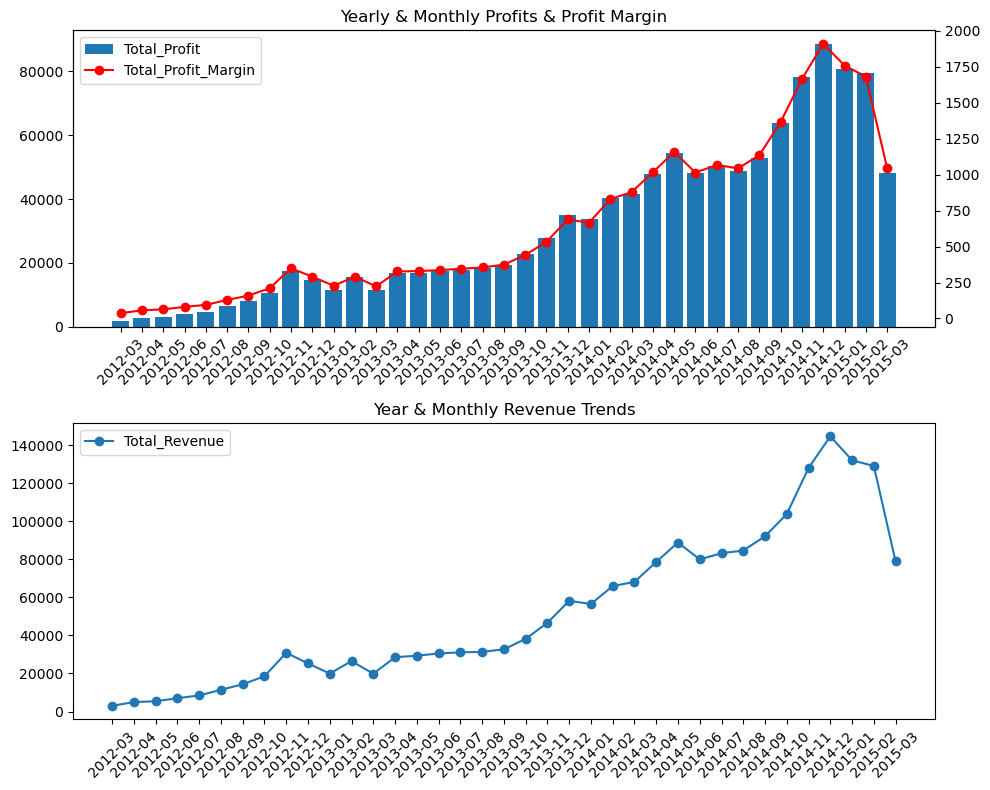

In [116]:
figure,axes = plt.subplots(2,1,figsize =(10,8))

axes[0].bar(revenue_profit_margin_summary['Year_Month'],revenue_profit_margin_summary['Total_Profits'],label = 'Total_Profit')
axes[0].tick_params(axis = 'x',rotation = 45)
axes[0].set_title('Yearly & Monthly Profits & Profit Margin')

axes1 = axes[0].twinx()
axes1.plot(revenue_profit_margin_summary['Year_Month'],revenue_profit_margin_summary['Total_Profit_Margin'],color = 'red',marker = 'o',label = 'Total_Profit_Margin')

lines,labels = axes[0].get_legend_handles_labels()
lines1,labels1 = axes1.get_legend_handles_labels()
axes[0].legend(lines + lines1,labels+labels1,loc='upper left')
    
axes[1].plot(revenue_profit_margin_summary['Year_Month'],revenue_profit_margin_summary['Total_Revenue'],marker = 'o',label = 'Total_Revenue')
axes[1].tick_params(axis = 'x',rotation = 45)
axes[1].set_title('Year & Monthly Revenue Trends')
axes[1].legend(loc='upper left')
plt.tight_layout()

In [117]:
order_items_order_refunds['quarters'] = order_items_order_refunds['created_at_order_items'].dt.quarter

In [118]:
order_items_order_refunds['years'] = order_items_order_refunds['created_at_order_items'].dt.year

In [119]:
order_items_order_refunds['years'].unique()

array([2012, 2013, 2014, 2015])

In [120]:
order_items_order_refunds['quarters'].unique()

array([1, 2, 3, 4])

In [121]:
revenue_profit_margin_quarter_summary = order_items_order_refunds.groupby(['years','quarters']).agg(Total_Profits = ('items_profit','sum') , Total_Profit_Margin = ('profit_margin' ,'sum'),Total_Revenue = ('price_usd','sum')).reset_index()

In [122]:
revenue_profit_margin_quarter_summary['year_quarter'] = revenue_profit_margin_quarter_summary['years'].astype('str') + '-Q' +  revenue_profit_margin_quarter_summary['quarters'].astype('str')

# Quarterly Revenue, Profit and Margin Performance

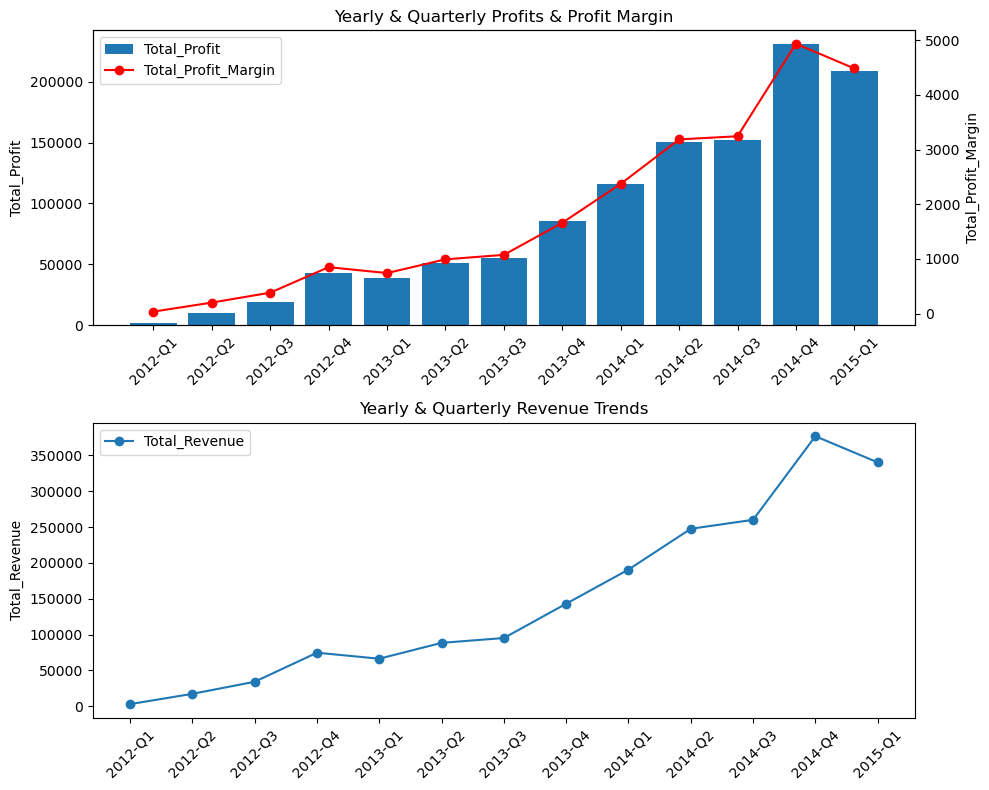

In [123]:
figure,axes =plt.subplots(2,1,figsize = (10,8))

axes[0].bar(revenue_profit_margin_quarter_summary['year_quarter'],revenue_profit_margin_quarter_summary['Total_Profits'],label = 'Total_Profit')
axes[0].tick_params(axis = 'x',rotation = 45)
axes[0].set_title('Yearly & Quarterly Profits & Profit Margin')
axes[0].set_ylabel('Total_Profit')
                   
axes1 = axes[0].twinx()
axes1.plot(revenue_profit_margin_quarter_summary['year_quarter'],revenue_profit_margin_quarter_summary['Total_Profit_Margin'],color = 'red',marker = 'o',label = 'Total_Profit_Margin')
axes1.set_ylabel('Total_Profit_Margin')

lines,labels = axes[0].get_legend_handles_labels()
lines1,labels1 = axes1.get_legend_handles_labels()
axes[0].legend(lines + lines1,labels+labels1,loc='upper left')
    
axes[1].plot(revenue_profit_margin_quarter_summary['year_quarter'],revenue_profit_margin_quarter_summary['Total_Revenue'],marker = 'o',label = 'Total_Revenue')
axes[1].tick_params(axis = 'x',rotation = 45)
axes[1].set_ylabel('Total_Revenue')
axes[1].set_title('Yearly & Quarterly Revenue Trends')
axes[1].legend(loc='upper left')
plt.tight_layout()

In [124]:
website_orders = website_sessions.merge(orders,how = 'left' , on = 'website_session_id',suffixes= ('_website_sessions','_orders'))

In [125]:
website_orders['created_at_website_sessions'] = pd.to_datetime(website_orders['created_at_website_sessions'])

C:\Users\Harshita Sahu\AppData\Local\Temp\ipykernel_20424\2762080659.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  website_orders['created_at_website_sessions'] = pd.to_datetime(website_orders['created_at_website_sessions'])


In [126]:
website_orders['quarter'] = website_orders['created_at_website_sessions'].dt.quarter
website_orders['year'] = website_orders['created_at_website_sessions'].dt.year
website_orders['year_quarter'] = website_orders['year'].astype('str') + '-Q' + website_orders['quarter'].astype('str')

In [127]:
quarter_wise_orders_sessions = website_orders.groupby('year_quarter').agg(Total_sessions = ('website_session_id','nunique'),Total_orders =('order_id','count')).reset_index()

# Quarterly Performance: Sessions vs Order Growth

Text(0, 0.5, 'Total_Orders')

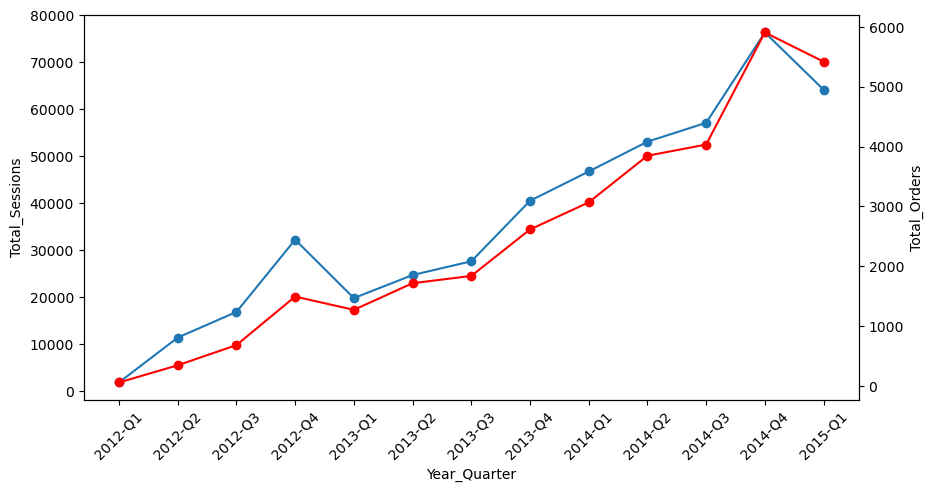

In [128]:
figure,axes = plt.subplots(figsize = (10,5))
axes.plot(quarter_wise_orders_sessions['year_quarter'],quarter_wise_orders_sessions['Total_sessions'],marker = 'o')
axes.tick_params(axis = 'x',rotation = 45)
axes.set_ylabel('Total_Sessions')
axes.set_xlabel('Year_Quarter')

axes1 = axes.twinx()

axes1.plot(quarter_wise_orders_sessions['year_quarter'],quarter_wise_orders_sessions['Total_orders'],marker = 'o',color = 'red')
axes1.set_ylabel('Total_Orders')

In [129]:
orders['created_at'] = pd.to_datetime(orders['created_at'])

In [130]:
orders['Years'] = orders['created_at'].dt.year

In [131]:
yearly_revenue = orders.groupby('Years')['price_usd'].sum().reset_index(name = 'revenue')

# Yearly Revenue Trend

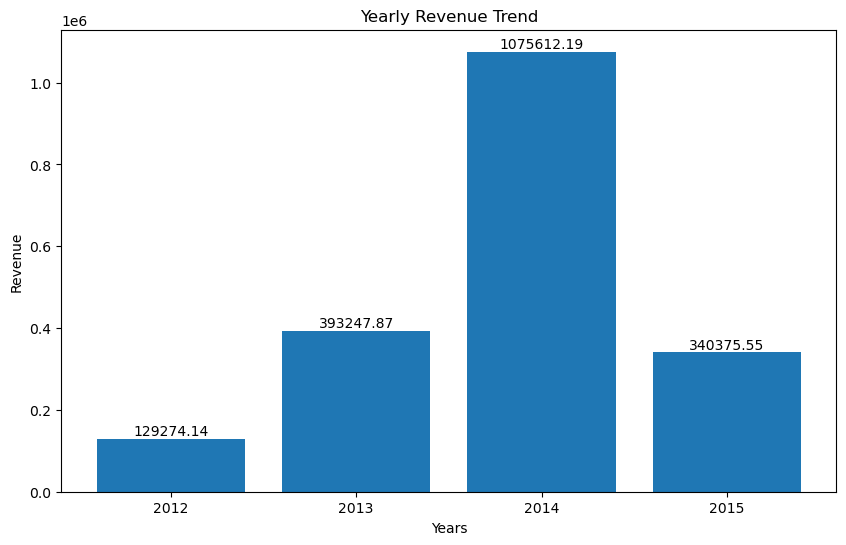

In [132]:
plt.figure(figsize = (10,6))
plt.bar(yearly_revenue['Years'] , yearly_revenue['revenue'])
for i,val in enumerate(yearly_revenue['revenue']):
    plt.text(yearly_revenue['Years'][i],val+0.05,str(val),va= 'bottom',ha = 'center')
plt.xticks(yearly_revenue['Years'])
plt.xlabel('Years')
plt.ylabel('Revenue')
plt.title('Yearly Revenue Trend')
plt.show()

In [133]:
## Yearly Profit & Profit Margin Trends 
yearl_profits_profit_margins = order_items_order_refunds.groupby('years').agg(Total_profits = ('items_profit','sum'), Total_Profit_Margins = ('profit_margin','sum')).reset_index()

# Total_Profits & Profit Margin Yearly Trends

Text(0, 0.5, 'Total_Profit_Margins')

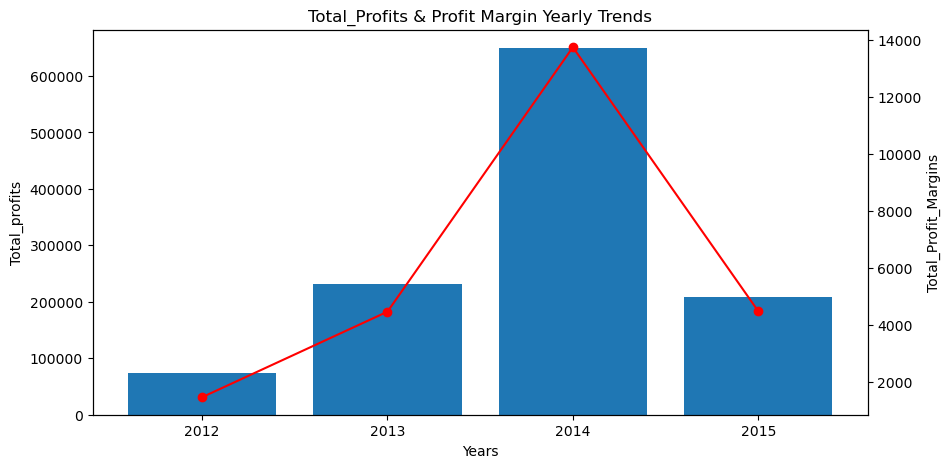

In [134]:
figure,axes = plt.subplots(figsize = (10,5))
axes.bar(yearl_profits_profit_margins['years'],yearl_profits_profit_margins['Total_profits'])
axes.set_xticks(yearl_profits_profit_margins['years'])
axes.set_xlabel('Years')
axes.set_ylabel('Total_profits')
axes.set_title('Total_Profits & Profit Margin Yearly Trends')

axes1 = axes.twinx()
axes1.plot(yearl_profits_profit_margins['years'],yearl_profits_profit_margins['Total_Profit_Margins'],color = 'red',marker= 'o')
axes1.set_ylabel('Total_Profit_Margins')

In [135]:
yearly_orders = orders.groupby('Years')['order_id'].count().reset_index(name = 'orders_count')

# Yearly Orders Trends

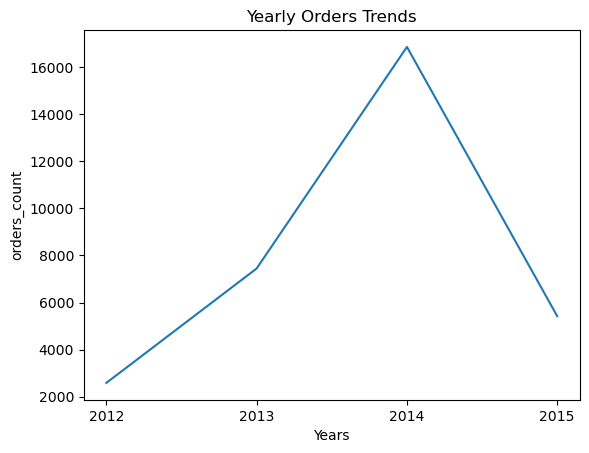

In [136]:
plt.title('Yearly Orders Trends')
plt.plot(yearly_orders['Years'],yearly_orders['orders_count'])
plt.xticks(yearly_orders['Years'])
plt.xlabel('Years')
plt.ylabel('orders_count')
plt.show()

In [137]:
visitors_customers_yearwise = website_orders.groupby('year').agg(Total_Customers = ('user_id_orders','count') , Total_Visitors = ('user_id_website_sessions','count')).reset_index()

# Yearly Visitors & Customers

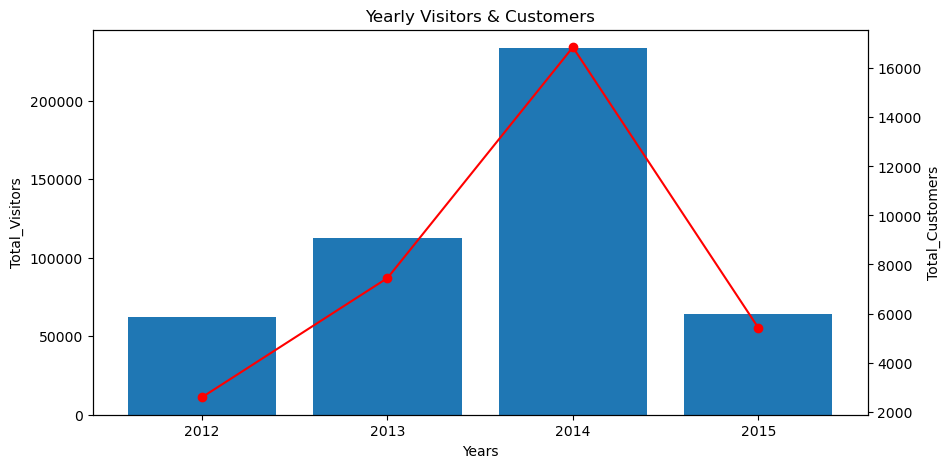

In [138]:
figure,axes = plt.subplots(figsize = (10,5))

axes.bar(visitors_customers_yearwise['year'],visitors_customers_yearwise['Total_Visitors'])
axes.set_xticks(visitors_customers_yearwise['year'])
axes.set_xlabel('Years')
axes.set_ylabel('Total_Visitors')

axes1 = axes.twinx()
axes1.plot(visitors_customers_yearwise['year'],visitors_customers_yearwise['Total_Customers'],color = 'red',marker = 'o')
axes1.set_xlabel('Years')
axes1.set_ylabel('Total_Customers')
axes1.set_title('Yearly Visitors & Customers')
plt.show()

In [139]:
# Quarterly Traffic Conversion Performance

quarterly_orders_sessions = website_orders.groupby('year_quarter').agg(Total_Orders = ('order_id','count') , Total_sessions = ('website_session_id','count')).reset_index()

In [140]:
quarterly_orders_sessions['conversion_rates'] = quarterly_orders_sessions['Total_Orders'] / quarterly_orders_sessions['Total_sessions']

# Quarterly Traffic and Conversion Performance

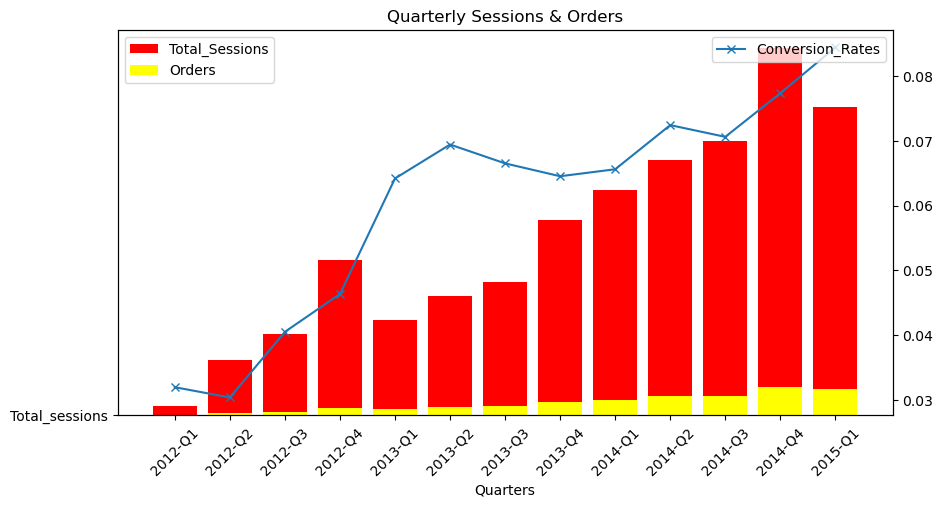

In [141]:
figure,axes = plt.subplots(figsize = (10,5))

axes.bar(quarterly_orders_sessions['year_quarter'],quarterly_orders_sessions['Total_sessions'],color = 'red',label = 'Total_Sessions')
axes.bar(quarterly_orders_sessions['year_quarter'],quarterly_orders_sessions['Total_Orders'],color = 'yellow',label= 'Orders',bottom='Total_sessions')
axes.set_xticks(quarterly_orders_sessions['year_quarter'])
axes.tick_params(axis = 'x',rotation = 45)
axes.set_title('Quarterly Sessions & Orders')
axes.set_xlabel('Quarters')

axes1 = axes.twinx()
axes1.plot(quarterly_orders_sessions['year_quarter'], quarterly_orders_sessions['conversion_rates'],marker = 'x',label = 'Conversion_Rates')


axes.legend()
axes1.legend(loc='upper right')
plt.show()

In [142]:
website_orders['Year_Month'] = website_orders['created_at_website_sessions'].dt.year.astype('str')+'-' + website_orders['created_at_website_sessions'].dt.month.astype('str').str.zfill(2) 

In [143]:
year_month_orders_sessions = website_orders.groupby('Year_Month').agg(Total_Orders = ('order_id','count') , Total_Sessions = ('website_session_id','count')).reset_index()

In [144]:
year_month_orders_sessions['conversion_rates'] = (year_month_orders_sessions['Total_Orders'] / year_month_orders_sessions['Total_Sessions'])*100.00

# Yearly & Monthly Sessions & Orders

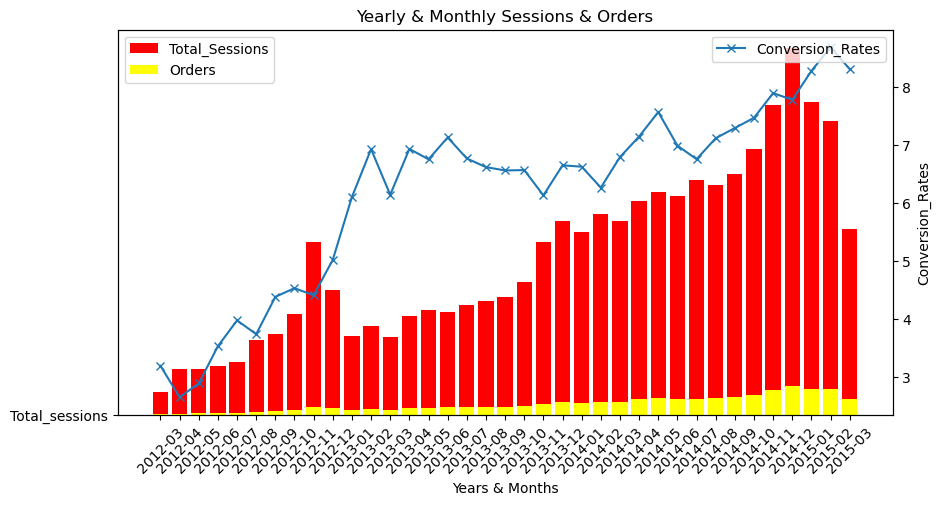

In [145]:
figure,axes = plt.subplots(figsize = (10,5))

axes.bar(year_month_orders_sessions['Year_Month'],year_month_orders_sessions['Total_Sessions'],color = 'red',label = 'Total_Sessions')
axes.bar(year_month_orders_sessions['Year_Month'],year_month_orders_sessions['Total_Orders'],color = 'yellow',label= 'Orders',bottom='Total_sessions')
axes.set_xticks(year_month_orders_sessions['Year_Month'])
axes.tick_params(axis = 'x',rotation = 45)
axes.set_title('Yearly & Monthly Sessions & Orders')
axes.set_xlabel('Years & Months')

axes1 = axes.twinx()
axes1.plot(year_month_orders_sessions['Year_Month'], year_month_orders_sessions['conversion_rates'],marker = 'x',label = 'Conversion_Rates')
axes1.set_ylabel('Conversion_Rates')

axes.legend()
axes1.legend(loc='upper right')
plt.show()

In [146]:
order_items_products = order_items.merge(products,how = 'left',left_on = 'product_id', right_on = 'product_id',suffixes= ('_order_items','_products'))

In [147]:
order_cross = order_items_products.groupby(['order_id','product_name','is_primary_item']).agg(Total_Order_Items = ('order_item_id','count'),Total_Revenue =('price_usd','sum')).reset_index()

In [148]:
order_cross_proo = order_cross.groupby('order_id')['Total_Order_Items'].count().reset_index(name = 'Order_items')
order_cross_proo = order_cross_proo[order_cross_proo['Order_items']==2]
order_cross_proo = order_items[order_items['order_id'].isin(order_cross_proo['order_id'])]
order_cross_proo =order_cross_proo.merge(products, on = 'product_id',how = 'left',suffixes=('_order_cross','_products'))
order_crossing = order_cross_proo.pivot(columns = 'is_primary_item',index = 'order_id',values = 'product_name').rename(columns={0:'Secondary_Item',1:'Primary_Item'}).reset_index()
order_crossing = order_crossing[order_crossing['Secondary_Item'].notna()]
order_crossing = order_crossing[order_crossing['Primary_Item']<order_crossing['Secondary_Item']]
order_crosss = order_crossing.merge(order_cross_proo,on = 'order_id',how = 'left')
order_crosss['cross_products'] = order_crosss['Primary_Item'] + ' + ' + order_crosss['Secondary_Item']
order_product_cross_sell = order_crosss.groupby('cross_products').agg(Total_Orders = ('order_id','nunique'),Total_Revenue = ('price_usd','sum')).reset_index()
order_product_cross_sell.to_csv('cross_combo_new.csv')

In [149]:
order_product_cross_sell

,cross_products,Total_Orders,Total_Revenue
0,The Birthday Sugar Panda + The Forever Love Bear,112,11869.76
1,The Birthday Sugar Panda + The Hudson River Mi...,640,48627.20
2,The Birthday Sugar Panda + The Original Mr. Fuzzy,277,26586.46
3,The Forever Love Bear + The Hudson River Mini ...,671,60376.58
4,The Forever Love Bear + The Original Mr. Fuzzy,72,7918.56
5,The Hudson River Mini bear + The Original Mr. ...,16,1279.68


In [150]:
order_items_order_counts = order_items.groupby('order_id')['order_item_id'].nunique().reset_index(name = 'order_items_counts')
orders_cross_sell = order_items[order_items['order_id'].isin(order_items_order_counts[order_items_order_counts['order_items_counts'] ==2]['order_id'])]
cross_sell = orders_cross_sell.merge(products, on = 'product_id',how ='left',suffixes= ('_cross_sell','_products'))
cross_sell_products = cross_sell.pivot(columns = 'is_primary_item',index = 'order_id',values = 'product_name')
cross_sell_products = cross_sell_products.reset_index()
cross_sell_products = cross_sell_products[cross_sell_products[0] <cross_sell_products[1] ]
cross_sell_products['cross_products_combosss'] = cross_sell_products[0] + ' + ' + cross_sell_products[1] 
cross_sell_products.groupby('cross_products_combosss')['order_id'].nunique()

cross_products_combosss
The Birthday Sugar Panda + The Forever Love Bear          136
The Birthday Sugar Panda + The Hudson River Mini bear      22
The Birthday Sugar Panda + The Original Mr. Fuzzy        1759
The Forever Love Bear + The Hudson River Mini bear          9
The Forever Love Bear + The Original Mr. Fuzzy            872
The Hudson River Mini bear + The Original Mr. Fuzzy      3126
Name: order_id, dtype: int64

# Most Frequently Bought Together Products

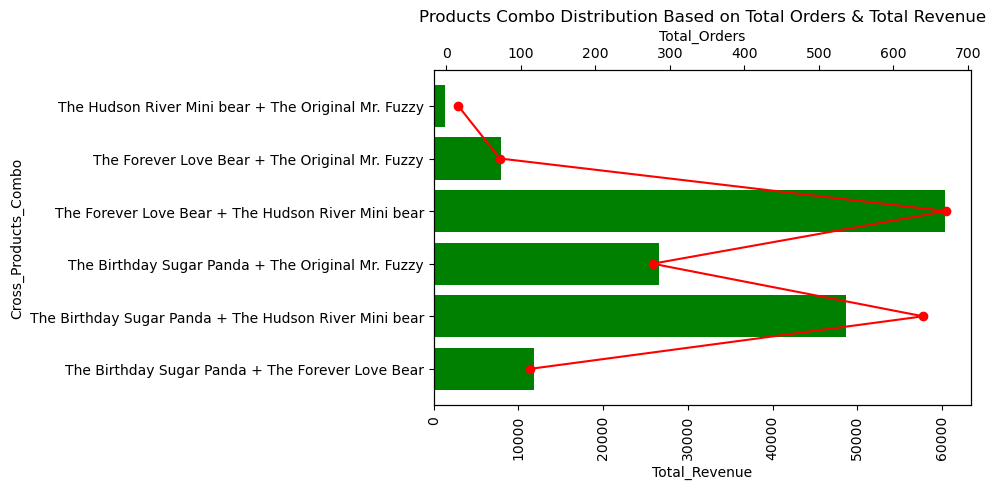

In [151]:
figure,axes = plt.subplots(figsize = (10,5))

axes.barh(order_product_cross_sell['cross_products'],order_product_cross_sell['Total_Revenue'],color = 'green',label = 'Total_Revenue')
axes.tick_params(axis = 'x',rotation = 90)
axes.set_xlabel('Total_Revenue')
axes.set_ylabel('Cross_Products_Combo')
axes.set_title('Products Combo Distribution Based on Total Orders & Total Revenue')

axes1 = axes.twiny()
axes1.plot(order_product_cross_sell['Total_Orders'],order_product_cross_sell['cross_products'],label = 'Total_Orders' , color = 'red',marker='o')
axes1.set_xlabel('Total_Orders')
plt.tight_layout()

In [152]:
oorder_items_order_counts = (
    order_items
    .groupby('order_id')['order_item_id']
    .nunique()
    .reset_index(name='order_items_counts')
)

# 2️⃣ keep only orders with 2 items
orders_cross_sell = order_items[
    order_items['order_id'].isin(
        order_items_order_counts[
            order_items_order_counts['order_items_counts'] == 2
        ]['order_id']
    )
]

# 3️⃣ add product names
cross_sell = orders_cross_sell.merge(
    products,
    on='product_id',
    how='left'
)

# 4️⃣ separate primary and cross-sell products
cross_sell_products = cross_sell.pivot(
    columns='is_primary_item',
    index='order_id',
    values='product_name'
)

# 5️⃣ reset index
cross_sell_products = cross_sell_products.reset_index()

# 6️⃣ create product combo
cross_sell_products['cross_products_combo'] = (
    cross_sell_products[0] + ' + ' + cross_sell_products[1]
)

# 7️⃣ count combos
combo_counts = cross_sell_products.groupby('cross_products_combo')['order_id'].nunique()

print(combo_counts)

cross_products_combo
The Birthday Sugar Panda + The Forever Love Bear          136
The Birthday Sugar Panda + The Hudson River Mini bear      22
The Birthday Sugar Panda + The Original Mr. Fuzzy        1759
The Forever Love Bear + The Birthday Sugar Panda          112
The Forever Love Bear + The Hudson River Mini bear          9
The Forever Love Bear + The Original Mr. Fuzzy            872
The Hudson River Mini bear + The Birthday Sugar Panda     640
The Hudson River Mini bear + The Forever Love Bear        671
The Hudson River Mini bear + The Original Mr. Fuzzy      3126
The Original Mr. Fuzzy + The Birthday Sugar Panda         277
The Original Mr. Fuzzy + The Forever Love Bear             72
The Original Mr. Fuzzy + The Hudson River Mini bear        16
Name: order_id, dtype: int64


In [153]:

order_items_products['product_type'] = np.where(order_items_products['is_primary_item'] == 0,'Second_Product','First_Product') 

In [154]:
first_second_products = order_items_products.groupby(['product_type','product_name'])['order_id'].count().reset_index(name = 'orders_counts')

In [155]:
first_second_products['product_type_product_name'] = first_second_products['product_type'] + ' + ' + first_second_products['product_name']

# Primary vs Secondary Product Purchase Trends

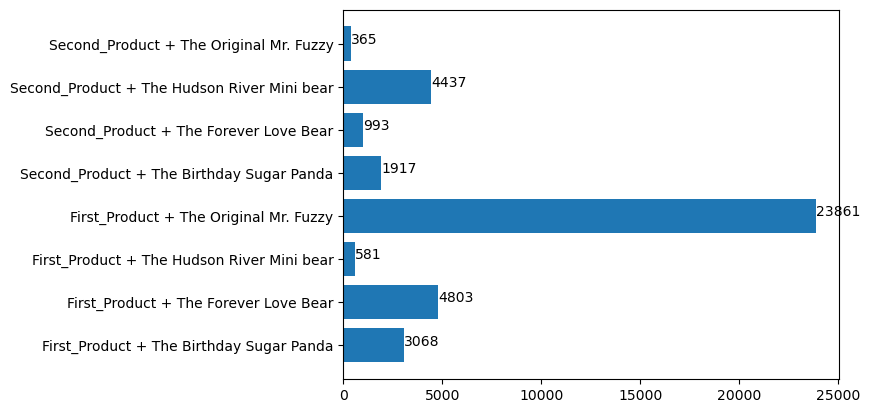

In [156]:
barhplots = plt.barh(first_second_products['product_type_product_name'],first_second_products['orders_counts'])
for i,val in enumerate(first_second_products['orders_counts']):
    plt.text(val+0.05,i,str(val))

In [157]:
second_product_contr = first_second_products[first_second_products['product_type'] == 'Second_Product']

In [158]:
second_product_contr

,product_type,product_name,orders_counts,product_type_product_name
4,Second_Product,The Birthday Sugar Panda,1917,Second_Product + The Birthday Sugar Panda
5,Second_Product,The Forever Love Bear,993,Second_Product + The Forever Love Bear
6,Second_Product,The Hudson River Mini bear,4437,Second_Product + The Hudson River Mini bear
7,Second_Product,The Original Mr. Fuzzy,365,Second_Product + The Original Mr. Fuzzy


# Distribution of Products Purchased as the Second Item

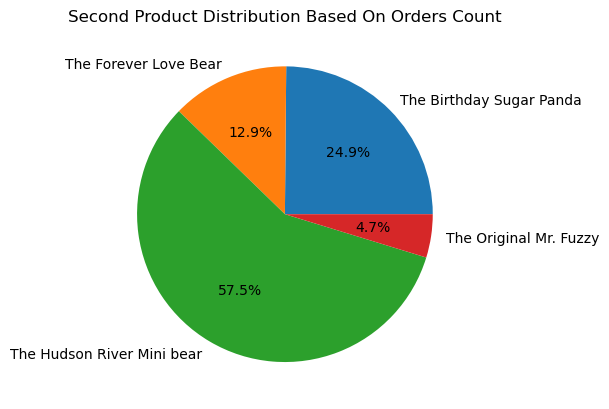

In [159]:
plt.pie(second_product_contr['orders_counts'],labels = second_product_contr['product_name'],autopct = '%1.1f%%')
plt.title('Second Product Distribution Based On Orders Count')
plt.show()

In [160]:
two_combo = order_items_products.groupby('order_id')['order_item_id'].nunique().reset_index(name = 'order_counts')
two_combo = two_combo[two_combo['order_counts']==2]
two_combos = order_items_products[order_items_products['order_id'].isin(two_combo['order_id'])]
two_combos_first_product = two_combos[two_combos['product_type'] == 'First_Product']
two_combos_second_product = two_combos[two_combos['product_type'] == 'Second_Product']
merge_first_second = two_combos_first_product.merge(two_combos_second_product, on = 'order_id',how = 'left',suffixes = ('_first_pro','_second_pro'))
upsell_pro = merge_first_second[merge_first_second['price_usd_second_pro']>merge_first_second['price_usd_first_pro']]

In [161]:
products_upsell_rates = (upsell_pro.groupby('product_name_second_pro')['order_id'].count()/two_combos_first_product['order_id'].nunique()).reset_index(name = 'upsell_rates')
products_upsell_rates['upsell_rates'] = products_upsell_rates['upsell_rates'].round(4)

# Upsell Performance Across Products

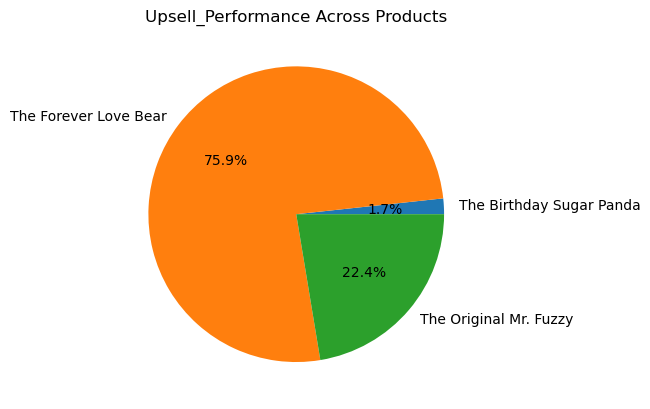

In [162]:
plt.title('Upsell_Performance Across Products')
plt.pie(products_upsell_rates['upsell_rates'],labels = products_upsell_rates['product_name_second_pro'],autopct = '%1.1f%%')
plt.show()

In [163]:
products_upsell_rates

,product_name_second_pro,upsell_rates
0,The Birthday Sugar Panda,0.0029
1,The Forever Love Bear,0.1288
2,The Original Mr. Fuzzy,0.0380


In [164]:
orders_profits_product_name = order_items_order_refunds.merge(products,on = 'product_id',how = 'left')
orders_profits_product_name['Months'] = orders_profits_product_name['created_at_order_items'].dt.month
orders_profits_product_name = orders_profits_product_name.groupby(['product_name','Months'])['items_profit'].sum().reset_index(name = 'Profits')

# Profit Contribution by Product (Monthly)

<Figure size 1000x800 with 0 Axes>

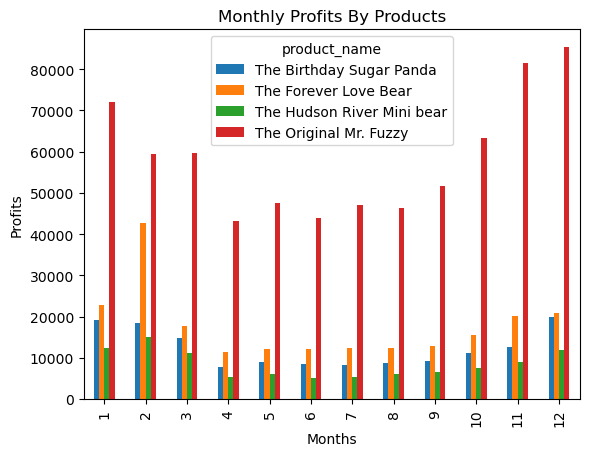

In [165]:
plt.figure(figsize = (10,8))
pivot = orders_profits_product_name.pivot(index = 'Months',columns = 'product_name',values = 'Profits')
pivot.plot(kind = 'bar')
plt.ylabel('Profits')
plt.title('Monthly Profits By Products')
plt.show()

In [166]:
website_pageviews['pageview_url'].unique()

array(['/home', '/products', '/the-original-mr-fuzzy', '/cart',
       '/shipping', '/billing', '/thank-you-for-your-order', '/lander-1',
       '/billing-2', '/the-forever-love-bear', '/lander-2', '/lander-3',
       '/the-birthday-sugar-panda', '/lander-4', '/lander-5',
       '/the-hudson-river-mini-bear'], dtype=object)

In [167]:
website_pageviews[website_pageviews['pageview_url'] == '/cart']['website_session_id'].nunique()

94953

In [168]:
website_pageviews.groupby('pageview_url')['website_session_id'].count()

pageview_url
/billing                         3617
/billing-2                      48441
/cart                           94953
/home                          137576
/lander-1                       47574
/lander-2                      131170
/lander-3                       79000
/lander-4                        9385
/lander-5                       68166
/products                      261231
/shipping                       64484
/thank-you-for-your-order       32313
/the-birthday-sugar-panda       19046
/the-forever-love-bear          26033
/the-hudson-river-mini-bear      2610
/the-original-mr-fuzzy         162525
Name: website_session_id, dtype: int64

In [169]:
website_pageviews['website_session_id'].nunique()

472871

In [170]:
website_sessions['website_session_id'].nunique()

472871

In [171]:
website_pageviews['created_at'] = pd.to_datetime(website_pageviews['created_at'] )

In [172]:
dated = website_pageviews[website_pageviews['pageview_url'] == '/billing-2']['created_at'].min()
two_months_ahead = dated+ pd.DateOffset(months = 2)
two_months_back = dated- pd.DateOffset(months = 2)
ab_test = website_pageviews[(website_pageviews['created_at']>=two_months_back) & (website_pageviews['created_at']<=two_months_ahead)]
ab_bill_test = ab_test[ab_test['pageview_url'].isin(['/billing','/billing-2'])].drop_duplicates("website_session_id")
ab_bill_test_orders = ab_bill_test.merge(orders , on = 'website_session_id',how = 'left',suffixes=('_ab_test','_orders'))
ab_bill_test_orders['test_period'] = np.where(ab_bill_test_orders['created_at_ab_test']>=dated,'After_billing_2','Before_billing_2')
ab_bill_test_orders.groupby(['pageview_url','test_period'])['price_usd'].sum()

pageview_url  test_period     
/billing      After_billing_2     14997.00
              Before_billing_2    21195.76
/billing-2    After_billing_2     20495.90
Name: price_usd, dtype: float64

In [173]:
website_pageviews[website_pageviews['pageview_url'] == '/lander-1']['created_at'].min()

Timestamp('2012-06-19 00:35:54')

In [174]:
#### kpis 
orders['order_id'].nunique()

32313

In [175]:
order_items_refundeddd = order_items.merge(order_items_refunds,on = 'order_item_id',how = 'left',suffixes=('_order_items','_order_items_refund'))
order_items_refundeddd['refund_amtss'] = order_items_refundeddd['price_usd'] - np.where(order_items_refundeddd['refund_amount_usd'].fillna(0)==0,0,order_items_refundeddd['refund_amount_usd'])
order_items_refundeddd['refund_costss'] = order_items_refundeddd['cogs_usd'] - np.where(order_items_refundeddd['refund_amount_usd'].fillna(0)==0,0,order_items_refundeddd['cogs_usd'] )

In [176]:
order_items_refundeddd['profistss'] = order_items_refundeddd['refund_amtss'] - order_items_refundeddd['refund_costss']

In [177]:
(order_items_refundeddd['profistss'].sum()/order_items_refundeddd['refund_costss'].sum())*100.00

168.4233860154562

In [178]:
website_sesson_orders = website_sessions.merge(orders,on = 'website_session_id',how = 'left',suffixes=('_website_sessions','_orders'))

In [179]:
(website_sesson_orders['order_id'].nunique()/website_sesson_orders['website_session_id'].nunique())*100.00

6.833364702001179

In [180]:
websitesss_bounce = website_pageviews.groupby('website_session_id')['pageview_url'].nunique().reset_index(name = 'sessions_counts')
websitesss_bounce[websitesss_bounce['sessions_counts']==1]['website_session_id'].nunique()/website_pageviews['website_session_id'].nunique()

0.4475639233533035

In [181]:
#### website_sessions['Channel_Type'] = np.where(website_sessions['utm_source'].notna(),'Paid','Free')

In [190]:
orders_website_sessions = website_sessions.merge(orders,on = 'website_session_id',how = 'left',suffixes=('_website_sessions','_orders'))
orders_website_sessions

,website_session_id,created_at_website_sessions,user_id_website_sessions,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer,channel_type,channel_name,order_id,created_at_orders,user_id_orders,primary_product_id,items_purchased,price_usd,cogs_usd,Years
0,1,19-03-2012 08:04,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,Paid,Paid_Search,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1,2,19-03-2012 08:16,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,Paid,Paid_Search,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2,3,19-03-2012 08:26,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,Paid,Paid_Search,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
3,4,19-03-2012 08:37,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,Paid,Paid_Search,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,5,19-03-2012 09:00,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,Paid,Paid_Search,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472866,472867,19-03-2015 07:49,394314,0,gsearch,brand,g_ad_2,desktop,https://www.gsearch.com,Paid,Paid_Search,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
472867,472868,19-03-2015 07:54,394315,0,bsearch,nonbrand,b_ad_1,mobile,https://www.bsearch.com,Paid,Paid_Search,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
472868,472869,19-03-2015 07:55,394316,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,Paid,Paid_Search,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
472869,472870,19-03-2015 07:56,394317,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,Paid,Paid_Search,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [191]:
summary = orders_website_sessions.groupby('channel_name').agg(Total_Orders = ('order_id','nunique') , Total_sessions = ('website_session_id','nunique')).reset_index()

In [192]:
summary['conversion_rate'] = summary['Total_Orders']/summary['Total_sessions']

In [193]:
orders_website_sessions['created_at_website_sessions'] = pd.to_datetime(orders_website_sessions['created_at_website_sessions'])

C:\Users\Harshita Sahu\AppData\Local\Temp\ipykernel_20424\2934557048.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  orders_website_sessions['created_at_website_sessions'] = pd.to_datetime(orders_website_sessions['created_at_website_sessions'])


In [194]:
orders_website_sessions['sessions_years'] = orders_website_sessions['created_at_website_sessions'].dt.year
orders_website_sessions['sessions_months'] = orders_website_sessions['created_at_website_sessions'].dt.month

In [195]:
order_session_year_months = orders_website_sessions.groupby(['sessions_months','sessions_years']).agg(Total_Orders = ('order_id','nunique'), Total_Sessions = ('website_session_id','nunique')).reset_index()
order_session_year_months['conversion_rates'] =order_session_year_months['Total_Orders']/order_session_year_months['Total_Sessions']

In [196]:
order_session_year_months

,sessions_months,sessions_years,Total_Orders,Total_Sessions,conversion_rates
0,1,2013,391,6401,0.061084
1,1,2014,983,14825,0.066307
2,1,2015,2099,25337,0.082843
3,2,2013,497,7168,0.069336
4,2,2014,1021,16285,0.062696
5,2,2015,2067,23778,0.086929
6,3,2012,60,1879,0.031932
7,3,2013,385,6264,0.061462
8,3,2014,1065,15669,0.067969
9,3,2015,1254,15083,0.083140


In [197]:
pages_bounce = website_pageviews.groupby('pageview_url')['website_session_id'].nunique().reset_index(name = 'session_counts')
pages_bounce

,pageview_url,session_counts
0,/billing,3617
1,/billing-2,48441
2,/cart,94953
3,/home,137576
4,/lander-1,47574
5,/lander-2,131170
6,/lander-3,79000
7,/lander-4,9385
8,/lander-5,68166
9,/products,261231


In [198]:
bouncesss = website_pageviews.groupby('website_session_id').size().reset_index(name = 'sessions_counts')
bouncesss_website_sessions = website_pageviews[website_pageviews['website_session_id'].isin(bouncesss[bouncesss['sessions_counts'] == 1]['website_session_id'])]
bouncesss_website_sessions_bounce_summary = bouncesss_website_sessions.groupby('pageview_url')['website_session_id'].size()/website_pageviews.groupby('pageview_url')['website_session_id'].nunique()
bouncesss_website_sessions_bounce_summary.fillna(0)

pageview_url
/billing                       0.000000
/billing-2                     0.000000
/cart                          0.000000
/home                          0.416831
/lander-1                      0.532434
/lander-2                      0.451696
/lander-3                      0.502949
/lander-4                      0.516889
/lander-5                      0.368674
/products                      0.000000
/shipping                      0.000000
/thank-you-for-your-order      0.000000
/the-birthday-sugar-panda      0.000000
/the-forever-love-bear         0.000000
/the-hudson-river-mini-bear    0.000000
/the-original-mr-fuzzy         0.000000
Name: website_session_id, dtype: float64

In [ ]:
website_pageviews['pageview_url'].unique()

In [ ]:
website_pageviews['Funnel']= np.where(website_pageviews['pageview_url']=='/home','Home_Page',
         np.where(website_pageviews['pageview_url'].isin(['/products','/the-original-mr-fuzzy','/the-forever-love-bear','/the-birthday-sugar-panda','/the-hudson-river-mini-bear']),'Product_Page',
                  np.where(website_pageviews['pageview_url'].isin(['/billing','/billing-2']),'Billing_Page',
                           np.where(website_pageviews['pageview_url'].isin(['/shipping']),'Shipping_Page',
                                   'Landing_Page'))))

In [ ]:
website_page_ss_total = website_pageviews.groupby('Funnel')['website_session_id'].size()

In [ ]:
pgaes_couunts = website_pageviews.groupby('website_session_id')['website_pageview_id'].nunique().reset_index(name = 'website_counts')
funnel_page_wise = website_pageviews[website_pageviews['website_session_id'].isin(pgaes_couunts[pgaes_couunts['website_counts'] == 1]['website_session_id'])]
funnel_page_wise.groupby('Funnel')['website_session_id'].size()/website_pageviews.groupby('Funnel')['website_session_id'].size()

In [ ]:
order_websitesss = website_sessions.merge(orders, on = 'website_session_id',how = 'left',suffixes=('_wesbite_sessions','_orders'))

In [ ]:
order_websitesss['created_at_wesbite_sessions'] = pd.to_datetime(order_websitesss['created_at_wesbite_sessions'])
order_websitesss['created_at_wesbite_sessions_years'] = order_websitesss['created_at_wesbite_sessions'].dt.year

In [ ]:
order_websitesss['created_at_wesbite_sessions_quarters'] = order_websitesss['created_at_wesbite_sessions'].dt.quarter

In [ ]:
order_websitesss

In [ ]:
order_websitesss__ = order_websitesss[order_websitesss['channel_name'].isin(['Organic_Search','Direct'])]

In [ ]:
order_websitesss['channel_name'].unique()

In [ ]:

chnnelwise_orders = order_websitesss__.groupby(['created_at_wesbite_sessions_years','created_at_wesbite_sessions_quarters','channel_name'])['order_id'].nunique()
chnnelwise_orders = chnnelwise_orders.reset_index(name = 'order_counts')

In [ ]:
chnnelwise_orders['year_quarters'] = chnnelwise_orders['created_at_wesbite_sessions_years'].astype('str') + '-' + chnnelwise_orders['created_at_wesbite_sessions_quarters'].astype('str')

In [ ]:
chnnelwise_orders = chnnelwise_orders.groupby(['year_quarters','channel_name'])['order_counts'].sum().reset_index()

In [ ]:
sns.lineplot(data = chnnelwise_orders, x = 'year_quarters',y = 'order_counts',hue = 'channel_name')
plt.xticks(rotation = 90)
plt.show()

In [ ]:
chnnelwise_orders

In [ ]:
o_wb = website_sessions.merge(orders,on = 'website_session_id',how = 'left',suffixes= ('_orders','_website_sessions'))
o_wb['order_id'].nunique()*100.00/o_wb['website_session_id'].nunique()

In [ ]:
wbb = website_sessions.copy()
wbb